# 1. 문제 정의
주어진 제품 및 매장 특성을 기반으로 판매금액(Item_Outlet_Sales) 예측

In [1]:
# 라이브러리 및 데이터 불러오기
import pandas as pd
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
# train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch4/train.csv")
# test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch4/test.csv")

In [2]:
train

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,NCR06,12.500,Low Fat,0.006760,Household,42.8112,OUT013,1987,High,Tier 3,Supermarket Type1,639.1680
1,FDW11,12.600,Low Fat,0.048741,Breads,60.4194,OUT013,1987,High,Tier 3,Supermarket Type1,990.7104
2,FDH32,12.800,Low Fat,0.075997,Fruits and Vegetables,97.1410,OUT013,1987,High,Tier 3,Supermarket Type1,2799.6890
3,FDL52,6.635,Regular,0.046351,Frozen Foods,37.4506,OUT017,2007,NaN,Tier 2,Supermarket Type1,1176.4686
4,FDO09,13.500,Regular,0.125170,Snack Foods,261.4910,OUT013,1987,High,Tier 3,Supermarket Type1,3418.8830
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,NCC54,17.750,Low Fat,0.097863,Health and Hygiene,239.3196,OUT049,1999,Medium,Tier 1,Supermarket Type1,3615.2940
6814,NCF19,13.000,Low Fat,0.035252,Household,48.0034,OUT018,2009,Medium,Tier 3,Supermarket Type2,923.4646
6815,FDU11,4.785,Low Fat,0.092576,Breads,121.0098,OUT035,2004,Small,Tier 2,Supermarket Type1,2530.7058
6816,FDK14,6.980,Low Fat,0.041189,Canned,82.8934,OUT045,2002,NaN,Tier 2,Supermarket Type1,818.9340


In [4]:
test

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDO38,17.250,Low Fat,0.073251,Canned,76.4986,OUT017,2007,NaN,Tier 2,Supermarket Type1
1,FDO32,6.360,Low Fat,0.120544,Fruits and Vegetables,45.8060,OUT046,1997,Small,Tier 1,Supermarket Type1
2,FDT14,10.695,Regular,0.128247,Dairy,121.8440,OUT018,2009,Medium,Tier 3,Supermarket Type2
3,FDG50,7.405,Low Fat,0.015296,Canned,89.7146,OUT049,1999,Medium,Tier 1,Supermarket Type1
4,FDR11,10.500,Regular,0.142760,Breads,159.3578,OUT049,1999,Medium,Tier 1,Supermarket Type1
...,...,...,...,...,...,...,...,...,...,...,...
1700,NCU18,NaN,Low Fat,0.097769,Household,142.4496,OUT019,1985,Small,Tier 1,Grocery Store
1701,FDY02,NaN,Regular,0.153457,Dairy,264.0910,OUT019,1985,Small,Tier 1,Grocery Store
1702,FDI09,20.750,Regular,0.129864,Seafood,240.1880,OUT018,2009,Medium,Tier 3,Supermarket Type2
1703,DRH23,14.650,Low Fat,0.171282,Hard Drinks,54.0614,OUT017,2007,NaN,Tier 2,Supermarket Type1


# 2. 탐색적 데이터 분석(EDA)

In [7]:
# train.head()
# train.tail()
train.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
6061,NCM05,6.825,Low Fat,0.059836,Health and Hygiene,264.3226,OUT035,2004,Small,Tier 2,Supermarket Type1,4229.1616
338,FDI46,9.500,Low Fat,0.074648,Snack Foods,253.3724,OUT018,2009,Medium,Tier 3,Supermarket Type2,755.0172
6607,FDY46,18.600,Low Fat,0.047964,Snack Foods,185.0898,OUT049,1999,Medium,Tier 1,Supermarket Type1,2993.4368
2977,DRF27,NaN,Low Fat,0.049755,Dairy,152.1340,OUT019,1985,Small,Tier 1,Grocery Store,153.1340
108,FDW16,NaN,Regular,0.041273,Frozen Foods,91.6804,OUT027,1985,Medium,Tier 3,Supermarket Type3,3858.9768


In [3]:
train.shape, test.shape

((6818, 12), (1705, 11))

In [5]:
train.info() 
# 결측치 확인 -> Item_Weight, Outlet_Size

# object 확인 
# Item_Identifier, Item_Fat_Content, Item_Type, 
# Outlet_Identifier, Outlet_Size, Outlet_Location_Type, Outlet_Type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            6818 non-null   object 
 1   Item_Weight                5656 non-null   float64
 2   Item_Fat_Content           6818 non-null   object 
 3   Item_Visibility            6818 non-null   float64
 4   Item_Type                  6818 non-null   object 
 5   Item_MRP                   6818 non-null   float64
 6   Outlet_Identifier          6818 non-null   object 
 7   Outlet_Establishment_Year  6818 non-null   int64  
 8   Outlet_Size                4878 non-null   object 
 9   Outlet_Location_Type       6818 non-null   object 
 10  Outlet_Type                6818 non-null   object 
 11  Item_Outlet_Sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 639.3+ KB


In [6]:
test.info()
# 결측치 확인 -> Item_Weight, Outlet_Size

# object 확인 
# Item_Identifier, Item_Fat_Content, Item_Type, 
# Outlet_Identifier, Outlet_Size, Outlet_Location_Type, Outlet_Type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            1705 non-null   object 
 1   Item_Weight                1404 non-null   float64
 2   Item_Fat_Content           1705 non-null   object 
 3   Item_Visibility            1705 non-null   float64
 4   Item_Type                  1705 non-null   object 
 5   Item_MRP                   1705 non-null   float64
 6   Outlet_Identifier          1705 non-null   object 
 7   Outlet_Establishment_Year  1705 non-null   int64  
 8   Outlet_Size                1235 non-null   object 
 9   Outlet_Location_Type       1705 non-null   object 
 10  Outlet_Type                1705 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 146.7+ KB


In [2]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,5656.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.872703,0.066121,140.419533,1997.885890,2190.941459
std,4.651034,0.051383,62.067861,8.339795,1706.131256
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.785000,0.026914,93.610050,1987.000000,836.577700
50%,12.600000,0.053799,142.448300,1999.000000,1806.648300
75%,17.000000,0.095273,185.060150,2004.000000,3115.944000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [9]:
test.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,1404.000000,1705.000000,1705.000000,1705.000000
mean,12.796984,0.066174,143.285107,1997.615836
std,4.613957,0.052465,63.063146,8.497423
min,4.555000,0.000000,31.955800,1985.000000
25%,8.710000,0.027571,94.743600,1987.000000
50%,12.600000,0.054234,144.512800,1999.000000
75%,16.700000,0.092927,187.755600,2004.000000
max,21.350000,0.311090,266.888400,2009.000000


In [10]:
train.describe(include="O")

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,6818,6818,6818,6818,4878,6818,6818
unique,1554,5,16,10,3,3,4
top,FDW26,Low Fat,Snack Foods,OUT046,Medium,Tier 3,Supermarket Type1
freq,9,4092,963,763,2228,2664,4474


In [9]:
print(train['Item_Identifier'].unique())
print(train['Item_Identifier'].value_counts())

['NCR06' 'FDW11' 'FDH32' ... 'FDO33' 'FDW60' 'FDU43']
Item_Identifier
FDW26    9
FDP25    9
DRN47    9
FDO19    9
NCI54    9
        ..
FDN51    1
FDQ60    1
FDO11    1
FDD48    1
FDG28    1
Name: count, Length: 1554, dtype: int64


In [10]:
train.isnull()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,False,False,False,False,False,False,False,False,False,False,False,False
6814,False,False,False,False,False,False,False,False,False,False,False,False
6815,False,False,False,False,False,False,False,False,False,False,False,False
6816,False,False,False,False,False,False,False,False,True,False,False,False


In [11]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1162
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1940
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [15]:
train.isnull().sum().sum()

3102

In [12]:
test.describe(include="O")

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,1705,1705,1705,1705,1235,1705,1705
unique,1077,5,16,10,3,3,4
top,FDG33,Low Fat,Fruits and Vegetables,OUT013,Medium,Tier 3,Supermarket Type1
freq,4,997,272,207,565,686,1103


In [11]:
test.isnull()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1700,False,True,False,False,False,False,False,False,False,False,False
1701,False,True,False,False,False,False,False,False,False,False,False
1702,False,False,False,False,False,False,False,False,False,False,False
1703,False,False,False,False,False,False,False,False,True,False,False


In [12]:
test.isnull().sum()

Item_Identifier                0
Item_Weight                  301
Item_Fat_Content               0
Item_Visibility                0
Item_Type                      0
Item_MRP                       0
Outlet_Identifier              0
Outlet_Establishment_Year      0
Outlet_Size                  470
Outlet_Location_Type           0
Outlet_Type                    0
dtype: int64

In [13]:
test.isnull().sum().sum()

771

# 3. 데이터 전처리

In [17]:
# y값 분할
target = train.pop('Item_Outlet_Sales')

In [18]:
target

0        639.1680
1        990.7104
2       2799.6890
3       1176.4686
4       3418.8830
          ...    
6813    3615.2940
6814     923.4646
6815    2530.7058
6816     818.9340
6817    1973.4312
Name: Item_Outlet_Sales, Length: 6818, dtype: float64

In [24]:
# 결측값 채우기(무게 : 최소값, 사이즈 : 최빈값)
train['Item_Weight'] = train['Item_Weight'].fillna(train['Item_Weight'].min()) # min : 4.555 로 채워짐
# train.describe() # 결측치 없음을 확인

# train.describe(include="O")
train['Outlet_Size'] = train['Outlet_Size'].fillna(train['Outlet_Size'].mode()[0])
# train.info() # 확인용

test['Item_Weight'] = test['Item_Weight'].fillna(test['Item_Weight'].min())
test['Outlet_Size'] = test['Outlet_Size'].fillna(test['Outlet_Size'].mode()[0])
# test.info() # 확인용

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            6818 non-null   object 
 1   Item_Weight                6818 non-null   float64
 2   Item_Fat_Content           6818 non-null   object 
 3   Item_Visibility            6818 non-null   float64
 4   Item_Type                  6818 non-null   object 
 5   Item_MRP                   6818 non-null   float64
 6   Outlet_Identifier          6818 non-null   object 
 7   Outlet_Establishment_Year  6818 non-null   int64  
 8   Outlet_Size                6818 non-null   object 
 9   Outlet_Location_Type       6818 non-null   object 
 10  Outlet_Type                6818 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 586.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 colu

In [25]:
train.describe() # 이상치 생략

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,6818.000000,6818.000000,6818.000000,6818.000000
mean,11.455107,0.066121,140.419533,1997.885890
std,5.265718,0.051383,62.067861,8.339795
min,4.555000,0.000000,31.290000,1985.000000
25%,6.690000,0.026914,93.610050,1987.000000
50%,11.000000,0.053799,142.448300,1999.000000
75%,16.100000,0.095273,185.060150,2004.000000
max,21.350000,0.328391,266.888400,2009.000000


In [27]:
# 레이블 인코딩(범주형 -> 수치형으로)
from sklearn.preprocessing import LabelEncoder
cols = train.columns[train.dtypes == object]
for col in cols:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]], axis=0)) # 행합치기
    train[col] = le.transform(train[col]) 
    test[col] = le.transform(test[col])

In [28]:
train # 확인작업

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,1467,12.500,1,0.006760,9,42.8112,1,1987,0,2,1
1,1075,12.600,1,0.048741,1,60.4194,1,1987,0,2,1
2,450,12.800,1,0.075997,6,97.1410,1,1987,0,2,1
3,613,6.635,2,0.046351,5,37.4506,2,2007,1,1,1
4,695,13.500,2,0.125170,13,261.4910,1,1987,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...
6813,1292,17.750,1,0.097863,8,239.3196,9,1999,1,0,1
6814,1317,13.000,1,0.035252,9,48.0034,3,2009,1,2,2
6815,975,4.785,1,0.092576,1,121.0098,6,2004,2,1,1
6816,549,6.980,1,0.041189,3,82.8934,7,2002,1,1,1


In [29]:
test # 확인작업

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,717,17.250,1,0.073251,3,76.4986,2,2007,1,1,1
1,712,6.360,1,0.120544,6,45.8060,8,1997,2,0,1
2,928,10.695,2,0.128247,4,121.8440,3,2009,1,2,2
3,423,7.405,1,0.015296,3,89.7146,9,1999,1,0,1
4,828,10.500,2,0.142760,1,159.3578,9,1999,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1700,1502,4.555,1,0.097769,9,142.4496,4,1985,2,0,0
1701,1168,4.555,2,0.153457,4,264.0910,4,1985,2,0,0
1702,474,20.750,2,0.129864,12,240.1880,3,2009,1,2,2
1703,69,14.650,1,0.171282,7,54.0614,2,2007,1,1,1


In [30]:
# 컬럼제거
train.drop('Item_Identifier', axis=1, inplace=True)
train.drop('Outlet_Identifier', axis=1, inplace=True)

test.drop('Item_Identifier', axis=1, inplace=True)
test.drop('Outlet_Identifier', axis=1, inplace=True)
train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,12.500,1,0.006760,9,42.8112,1987,0,2,1
1,12.600,1,0.048741,1,60.4194,1987,0,2,1
2,12.800,1,0.075997,6,97.1410,1987,0,2,1
3,6.635,2,0.046351,5,37.4506,2007,1,1,1
4,13.500,2,0.125170,13,261.4910,1987,0,2,1


# 4. 검증데이터 분할

In [31]:
# train : val = 8 : 2 = 학습용 : 검증용

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(train, target, test_size=0.2, random_state=0)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((5454, 9), (1364, 9), (5454,), (1364,))

# 5. 머신러닝 학습 및 평가

In [32]:
# MSE, MAE, R2 ...
# 선형회귀

from sklearn.linear_model import LinearRegression
lr = LinearRegression() # 모델 가져오기
lr.fit(X_train, y_train) # 학습
y_pred = lr.predict(X_val) # 예측
y_pred

array([3003.13357176, 1419.3387439 , 1756.59219627, ..., 2205.24901842,
       4237.1552263 , 3359.42873395])

In [33]:
# 평가지표 확인
from sklearn.metrics import mean_squared_error # MSE(평균제곱오차)
from sklearn.metrics import mean_absolute_error # MAE(평균절대오차)
from sklearn.metrics import root_mean_squared_error # RMSE(제곱평균오차)
from sklearn.metrics import r2_score # R2score(결정계수)

lr_mse = mean_squared_error(y_val, y_pred)
lr_mae = mean_absolute_error(y_val, y_pred)
lr_rmse = root_mean_squared_error(y_val, y_pred)
lr_r2 = r2_score(y_val, y_pred)

print("MSE : ", lr_mse) # 오차를 제곱해 평균을 낸 값 - 값 클수록 예측이 실제와 다름
print("MAE : ", lr_mae) # 오차를 절대값으로 계산 - 값 클수록 예측이 실제와 다름
print("RMSE : ", lr_rmse) #  
print("R2score : ", lr_r2) #

# MSE / MAE / RMSE 상대적인 기준
# 평균적으로 Y 평균값의 10% 이하 : 준수한 성능
# 평균적으로 Y 평균값의 10 - 30% : 보통
# Y 평균값의 30% 이상 : 낮은 성능
# 시험점수(0-100) 예측 -> RMSE = 10 - 문제
# 아파트가격(30평 - 평균 5억) 예측 -> RMSE=1000만원(2%) -> 오차작음(괜찮은 모델)

# R2(결정계수)
# 0.7 이상 : 좋은 모델
# 0.5 - 0.7 : 보통
# 0.3 - 0.5 : 낮은 모델

MSE :  1265376.5286150137
MAE :  861.1779558777841
RMSE :  1124.8895628527334
R2score :  0.5125757848943001


In [38]:
# LIGHTGBM 학습

import lightgbm as lgb
model = lgb.LGBMRegressor(random_state=0, verbose=-1)
model.fit(X_train, y_train)
y_pred_2 = model.predict(X_val)

lgm_mse = mean_squared_error(y_val, y_pred_2)
lgm_mae = mean_absolute_error(y_val, y_pred_2)
lgm_rmse = root_mean_squared_error(y_val, y_pred_2)
lgm_r2 = r2_score(y_val, y_pred_2)

print("MSE : ", lgm_mse) # 오차를 제곱해 평균을 낸 값 - 값 클수록 예측이 실제와 다름
print("MAE : ", lgm_mae) # 오차를 절대값으로 계산 - 값 클수록 예측이 실제와 다름
print("RMSE : ", lgm_rmse) 
print("R2score : ", lgm_r2) 

MSE :  1114002.6635464637
MAE :  735.6497591742841
RMSE :  1055.463245947704
R2score :  0.5708851384345557


In [ ]:
# 파일로 저장 - 실행시키지는 X 코드만 확인
# pred = model.predict(test)
# # pred

# submit = pd.DataFrame({'pred':pred})
# submit.to_csv("result.csv", index=False)

In [2]:
from statsmodels.formula.api import ols

model = ols('Item_Outlet_Sales ~ C(Item_Type)', data=train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.913
Date:                Thu, 30 Oct 2025   Prob (F-statistic):             0.0178
Time:                        00:19:51   Log-Likelihood:                -60399.
No. Observations:                6818   AIC:                         1.208e+05
Df Residuals:                    6802   BIC:                         1.209e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                              2026.5664     74.600     27.166      0.000    1880.326    2172.807
C(Item_Type)[T.Breads]                  148.0556    144.412      1.025      0.305    -135.038     431.149
C(Item_Type)[T.Breakfast]                74.8649    192.722      0.388      0.698    -302.931     452.661
C(Item_Type)[T.Canned]                  214.7920    105.756      2.031      0.042       7.478     422.106
C(Item_Type)[T.Dairy]                   228.7012    103.651      2.206      0.027      25.512     431.890
C(Item_Type)[T.Frozen Foods]            105.0973     98.536      1.067      0.286     -88.064     298.259
C(Item_Type)[T.Fruits and Vegetables]   260.9802     92.689      2.816      0.005      79.280     442.680
C(Item_Type)[T.Hard Drinks]              67.1994    150.179      0.447      0.655    -227.199     361.598
C(Item_Type)[T.Health and Hygiene]      -19.0033    112.020     -0.170      0.865    -238.598     200.591
C(Item_Type)[T.Household]               268.9886     97.753      2.752      0.006      77.362     460.615
C(Item_Type)[T.Meat]                    186.3949    117.751      1.583      0.113     -44.434     417.224
C(Item_Type)[T.Others]                 -119.3750    163.615     -0.730      0.466    -440.112     201.362
C(Item_Type)[T.Seafood]                 184.9549    252.322      0.733      0.464    -309.674     679.584
C(Item_Type)[T.Snack Foods]             249.8813     92.639      2.697      0.007      68.281     431.482
C(Item_Type)[T.Soft Drinks]             -12.5716    118.261     -0.106      0.915    -244.400     219.257
C(Item_Type)[T.Starchy Foods]           245.9885    175.575      1.401      0.161     -98.193     590.170
==============================================================================
Omnibus:                     1272.115   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2338.747
Skew:                           1.167   Prob(JB):                         0.00
Kurtosis:                       4.668   Cond. No.                         16.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

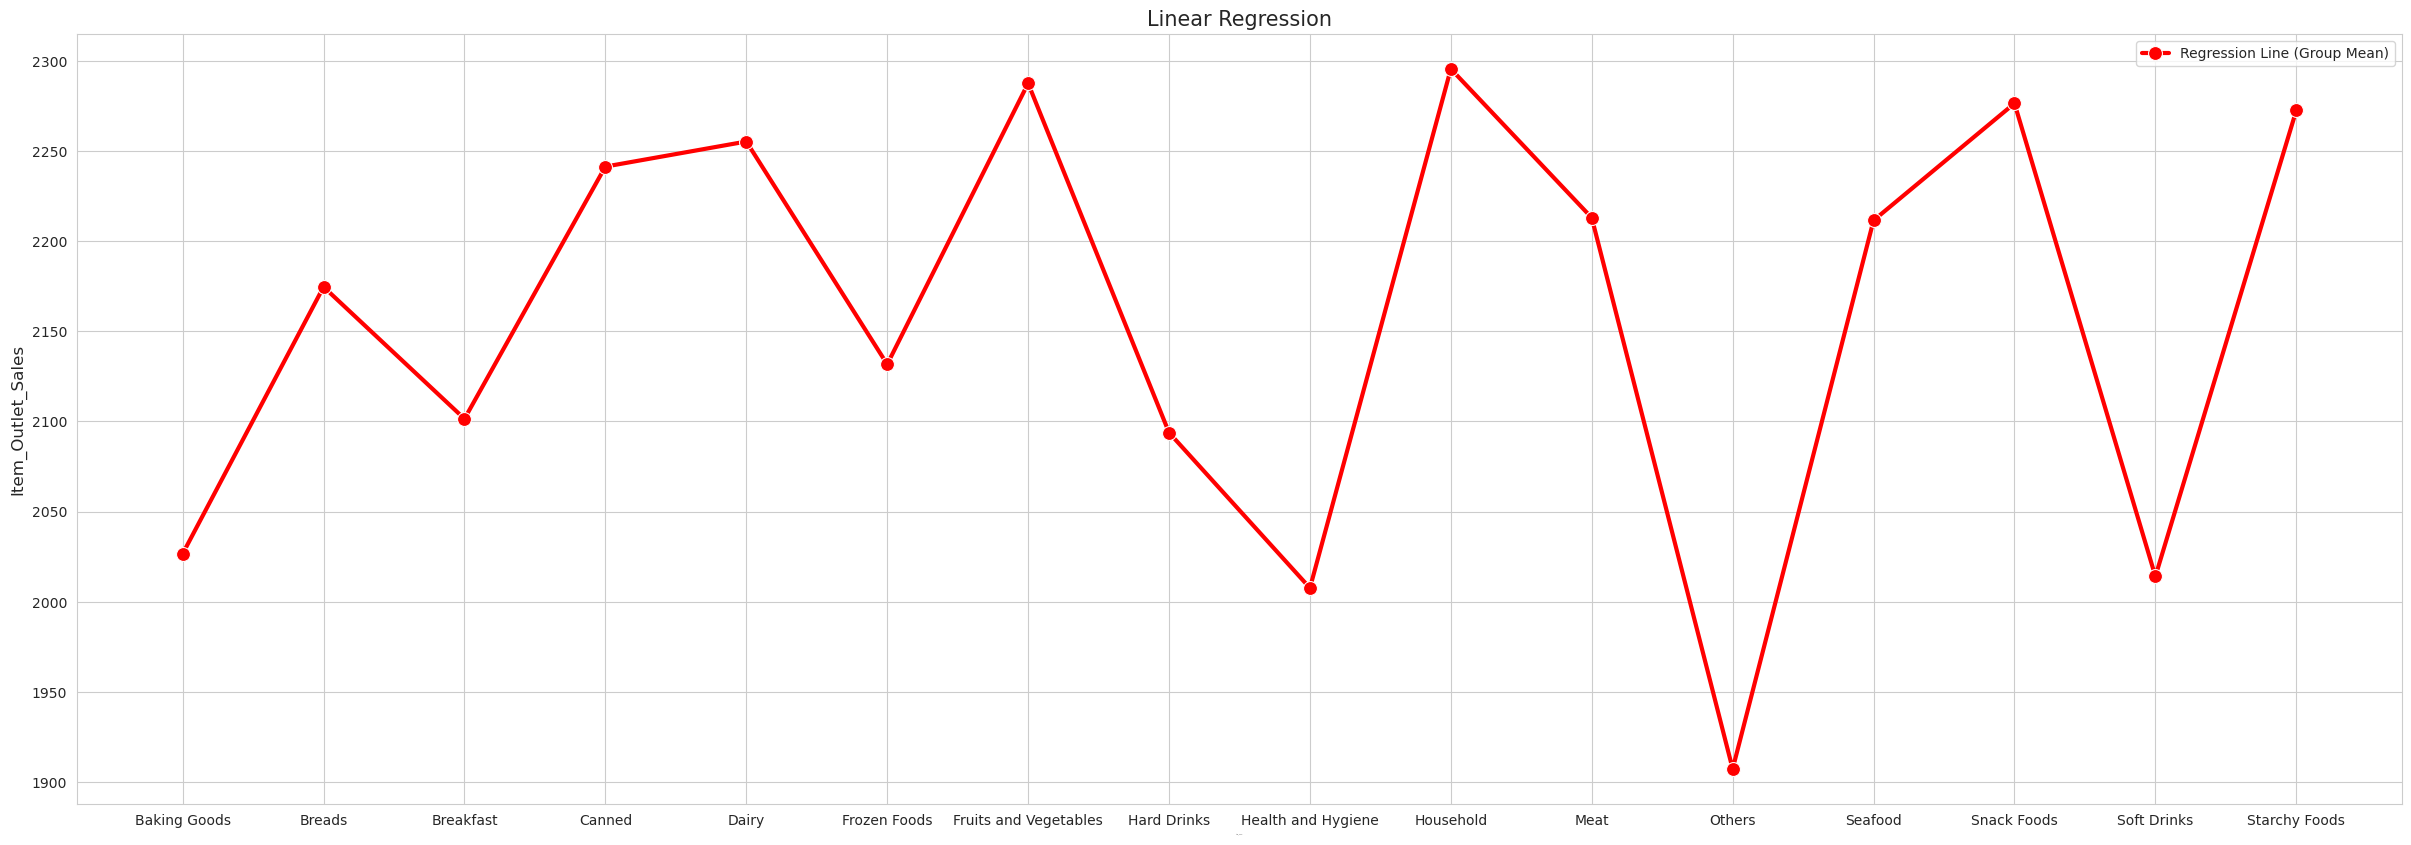

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

predictions = model.predict(train)
train['Predicted_Item_Outlet_Sales'] = predictions

plt.figure(figsize=(30, 10))
sns.set_style("whitegrid")
sns.lineplot(x='Item_Type', y='Predicted_Item_Outlet_Sales', data=train.sort_values('Item_Type'), 
             color='red', linewidth=3, marker='o', markersize=10, label='Regression Line (Group Mean)')

plt.title('Linear Regression', fontsize=15)
plt.xlabel('Item_Type', fontsize=1)
plt.ylabel('Item_Outlet_Sales', fontsize=12)
plt.legend()
plt.show()